In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split

In [3]:
df=pd.read_excel(r"C:\Users\Administrator\Downloads\myntra_dataset_ByScraping.xlsx")

In [4]:
df.head()

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings
0,WROGN,Men Loose Fit Cotton Jeans,1374,2499.0,0.45,4.2,57
1,Flying Machine,Men Slim Fit Jeans,1829,2999.0,0.39,4.6,5
2,Roadster,Men Pure Cotton Jeans,974,2499.0,0.61,3.6,1100
3,Bene Kleed,Relaxed Fit Denim Jeans,873,2299.0,0.62,4.0,4800
4,Levis,Men 511 Slim Fit Jeans,1478,2899.0,0.49,4.3,264


In [5]:
np.random.seed(42)
df['sales']=np.random.randint(10,1000,size=len(df))

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52120 entries, 0 to 52119
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand_name         52120 non-null  object 
 1   pants_description  52120 non-null  object 
 2   price              52120 non-null  int64  
 3   MRP                52120 non-null  float64
 4   discount_percent   52120 non-null  float64
 5   ratings            52120 non-null  float64
 6   number_of_ratings  52120 non-null  int64  
 7   sales              52120 non-null  int32  
dtypes: float64(3), int32(1), int64(2), object(2)
memory usage: 3.0+ MB


In [7]:
df.describe()

,price,MRP,discount_percent,ratings,number_of_ratings,sales
count,52120.000000,52120.000000,52120.000000,52120.000000,52120.000000,52120.000000
mean,1594.515445,3180.398438,1.648256,3.997794,91.568937,506.735303
std,1495.972325,2201.883218,4.687529,0.420404,433.918513,286.061223
min,337.000000,499.000000,0.020000,1.000000,5.000000,10.000000
25%,989.000000,2499.000000,0.400000,3.800000,16.000000,259.000000
50%,1439.000000,2999.000000,0.500000,4.000000,35.000000,510.000000
75%,1829.000000,3499.000000,0.630000,4.200000,74.000000,754.000000
max,54000.000000,72000.000000,64.000000,5.000000,30700.000000,999.000000


In [8]:
df.isna().sum()

brand_name           0
pants_description    0
price                0
MRP                  0
discount_percent     0
ratings              0
number_of_ratings    0
sales                0
dtype: int64

In [9]:
df.brand_name.value_counts()

brand_name
WROGN                        5303
Flying Machine               5197
United Colors of Benetton    3985
Roadster                     3523
Mufti                        2416
                             ... 
Happy2r                         1
INKD                            1
Bruun & Stengade                1
Nature Casuals                  1
Ed Hardy                        1
Name: count, Length: 417, dtype: int64

In [10]:
nobrands=df.brand_name.nunique()
print(f'number of brands are {nobrands}')

number of brands are 417


In [11]:
df.price.max()

54000

In [12]:
premium50=df.loc[df.price.nlargest(50).index]
premium50.head(10)

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings,sales
51228,Jacob Cohen,Men Slim Fit Mid-Rise Jeans,54000,72000.0,0.25,4.1,25,445
37202,Jacob Cohen,Men Slim Fit Jeans,53062,70750.0,0.25,4.6,5,924
37203,United Colors of Benetton,Men Relaxed Fit Mid-Rise Jeans,53062,70750.0,0.25,4.6,5,314
18538,Jacob Cohen,Men Jeans,51750,57500.0,0.10,3.9,31,280
18539,True Religion,Slim Fit Mid-Rise Jeans,51750,57500.0,0.10,3.9,31,123
37312,Jacob Cohen,Mid-Rise Straight Fit Jeans,44625,59500.0,0.25,4.2,42,708
37313,United Colors of Benetton,Men Slim Fit Mid-Rise Jeans,44625,59500.0,0.25,4.2,42,531
18505,Tramarossa,Men Slim Fit Mid-Rise Jeans,43875,58500.0,0.25,4.6,5,955
25103,Tramarossa,Men Jeans,43650,48500.0,0.10,4.6,5,543
25104,United Colors of Benetton,Men Relaxed Fit Mid-Rise Jeans,43650,48500.0,0.10,4.6,5,486


In [13]:
premium50=df.loc[df.price.nlargest(50).index]
premium50.brand_name.value_counts()

brand_name
True Religion                13
Tramarossa                   12
Jacob Cohen                   9
United Colors of Benetton     7
Versace Jeans Couture         4
7 For All Mankind             2
MEGHZ                         1
Karl Lagerfeld                1
Levis                         1
Name: count, dtype: int64

In [14]:
df.price.min()

337

In [15]:
df.price.value_counts()

price
1829     2481
1393     1745
2099     1645
1399     1508
1623     1365
         ... 
20625       1
1242        1
23250       1
16350       1
1421        1
Name: count, Length: 1485, dtype: int64

In [16]:
df['revenue']=df['price']*df['sales']

In [17]:
df.head()

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings,sales,revenue
0,WROGN,Men Loose Fit Cotton Jeans,1374,2499.0,0.45,4.2,57,112,153888
1,Flying Machine,Men Slim Fit Jeans,1829,2999.0,0.39,4.6,5,445,813905
2,Roadster,Men Pure Cotton Jeans,974,2499.0,0.61,3.6,1100,870,847380
3,Bene Kleed,Relaxed Fit Denim Jeans,873,2299.0,0.62,4.0,4800,280,244440
4,Levis,Men 511 Slim Fit Jeans,1478,2899.0,0.49,4.3,264,116,171448


In [18]:
TopRevenue=df.loc[df.revenue.nlargest(20).index]
TopRevenue.brand_name.value_counts()

brand_name
Tramarossa                   7
Jacob Cohen                  5
United Colors of Benetton    4
True Religion                2
Versace Jeans Couture        1
MEGHZ                        1
Name: count, dtype: int64

In [19]:
mini=df['price'].min()
maxi=df['price'].max()
print(f'prices range from {mini} to{maxi}')

prices range from 337 to54000


In [20]:
def pricecategory(df):
    if df['price']<=1000:
        return 'Economical'
    elif df['price']>=1000 and df['price']<=10000:
        return 'Affordable'
    elif df['price']>=10000 and df['price'] <=30000:
        return 'Premium'
    else:
        return 'Luxury'

In [21]:
df['fashioncategory']=df.apply(lambda x:pricecategory(x),axis=1)
df.head()

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings,sales,revenue,fashioncategory
0,WROGN,Men Loose Fit Cotton Jeans,1374,2499.0,0.45,4.2,57,112,153888,Affordable
1,Flying Machine,Men Slim Fit Jeans,1829,2999.0,0.39,4.6,5,445,813905,Affordable
2,Roadster,Men Pure Cotton Jeans,974,2499.0,0.61,3.6,1100,870,847380,Economical
3,Bene Kleed,Relaxed Fit Denim Jeans,873,2299.0,0.62,4.0,4800,280,244440,Economical
4,Levis,Men 511 Slim Fit Jeans,1478,2899.0,0.49,4.3,264,116,171448,Affordable


<Axes: xlabel='price', ylabel='Count'>

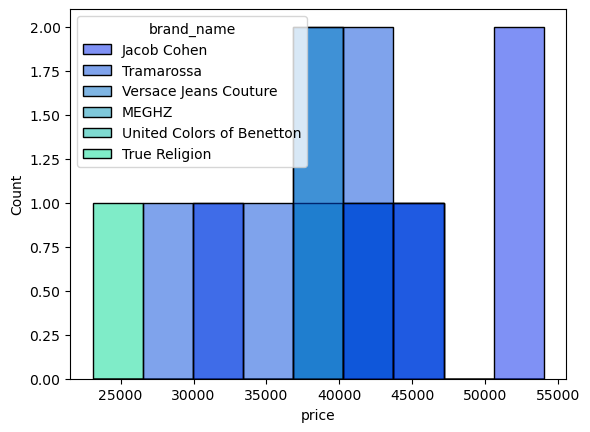

In [22]:
##price distribution

sns.histplot(TopRevenue,x=TopRevenue['price'],hue=TopRevenue['brand_name'],palette='winter')

<Axes: xlabel='count', ylabel='fashioncategory'>

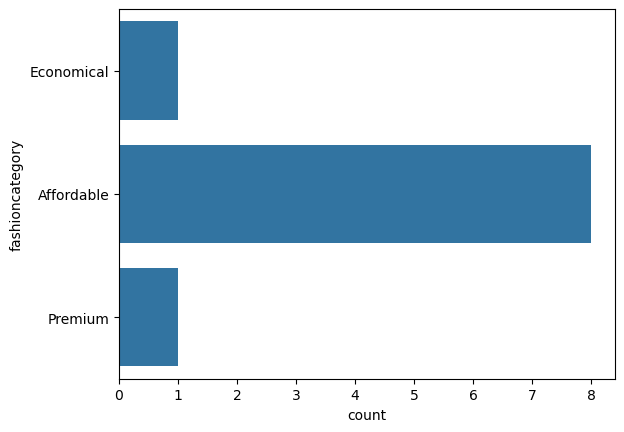

In [34]:
sns.countplot(Toprated['fashioncategory'])

In [26]:
luxbrands=df.loc[df['fashioncategory']=='Luxury']
luxbrands.brand_name.value_counts()

brand_name
Tramarossa                   10
Jacob Cohen                   9
United Colors of Benetton     6
True Religion                 4
Versace Jeans Couture         2
MEGHZ                         1
Name: count, dtype: int64

In [33]:
ecobrands=df.loc[df['fashioncategory']=='Economical']
ecobrands.brand_name.value_counts()

brand_name
Roadster                     3278
United Colors of Benetton     861
LINARIA                       811
glitchez                      795
COMFITS                       489
                             ... 
INKD                            1
boohooMAN                       1
Chapter 2                       1
Off Duty India                  1
Iconic                          1
Name: count, Length: 240, dtype: int64

In [32]:
Nlux=luxbrands.brand_name.nunique()
Neco=ecobrands.brand_name.nunique()
Npre=premiumbrands.brand_name.nunique()
Naff=affbrands.brand_name.nunique()
print(f'no. luxury brands {Nlux} ,economical brands are {Neco},premium are {Npre},afforable are {Naff}')

no. luxury brands 6 ,economical brands are 240,premium are 16,afforable are 344


In [28]:
premiumbrands=df.loc[df['fashioncategory']=='Premium']
premiumbrands.brand_name.value_counts()

brand_name
True Religion                66
United Colors of Benetton    14
7 For All Mankind            12
Calvin Klein Jeans            9
Polo Ralph Lauren             7
HACKETT LONDON                5
Versace Jeans Couture         3
Tramarossa                    2
Karl Lagerfeld                2
ADIDAS Originals              1
Levis                         1
Andamen                       1
Just Cavalli                  1
Snitch                        1
V-Mart                        1
JIMMY & JORDAN                1
Name: count, dtype: int64

In [29]:
affbrands=df.loc[df['fashioncategory']=='Affordable']
affbrands.brand_name.value_counts()

brand_name
Flying Machine               5167
WROGN                        5131
United Colors of Benetton    3104
Mufti                        2411
Levis                        2139
                             ... 
LEG UP                          1
Breakbounce                     1
ADIDAS Originals                1
Pupil London                    1
Ed Hardy                        1
Name: count, Length: 344, dtype: int64

In [30]:
Toprated=df[df['ratings']==5]
Toprated=Toprated.sort_values(by='ratings',ascending=False).head(10)
Toprated

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings,sales,revenue,fashioncategory
1597,Roadster,Washed Effect Jeans,890,2699.0,0.67,5.0,9,484,430760,Economical
38536,Flying Machine,Men Slim Fit Jeans,1549,2499.0,0.38,5.0,5,527,816323,Affordable
38103,United Colors of Benetton,Men Relaxed Fit Mid-Rise Jeans,1299,3599.0,23.00,5.0,6,450,584550,Affordable
38102,Pepe Jeans,Men Slim Fit Stretchable Jeans,1299,3599.0,23.00,5.0,6,667,866433,Affordable
37893,Octave,Men Mid-Rise Clean Look Jeans,1689,2599.0,0.35,5.0,5,203,342867,Affordable
35648,United Colors of Benetton,Men Anti Fit Mid-Rise Jeans,1749,3499.0,0.50,5.0,6,294,514206,Affordable
35647,SPYKAR,Men Relaxed Fit Jeans,1749,3499.0,0.50,5.0,6,578,1010922,Affordable
35646,WAIMEA,Men Bootcut Jeans,3849,6999.0,0.45,5.0,6,840,3233160,Affordable
35394,John Pride,Men Plus Size Jogger Jeans,3374,4499.0,0.25,5.0,5,979,3303146,Affordable
35164,True Religion,Men Skinny Fit Jeans,13199,21999.0,0.40,5.0,7,473,6243127,Premium


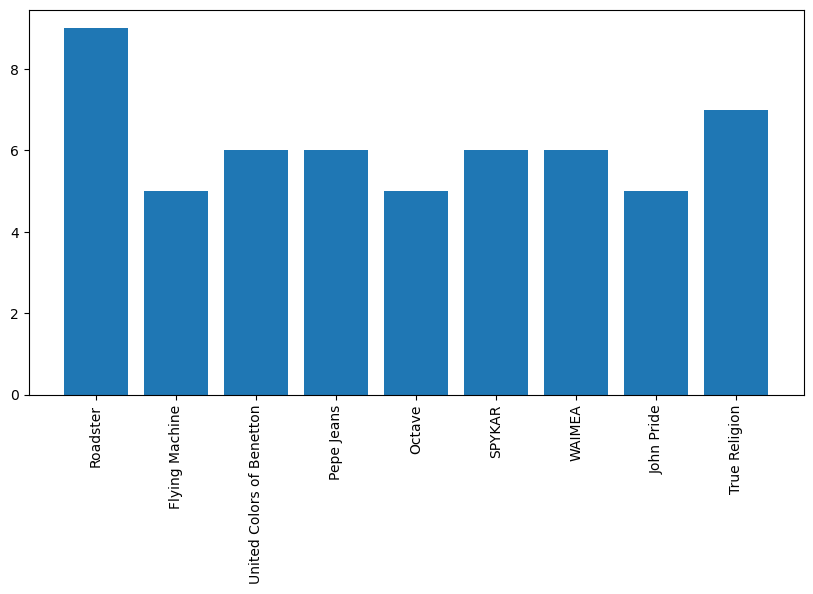

In [31]:
plt.figure(figsize=(10,5))
plt.bar(Toprated['brand_name'],Toprated['number_of_ratings'])
plt.xticks(rotation=90)
plt.show()

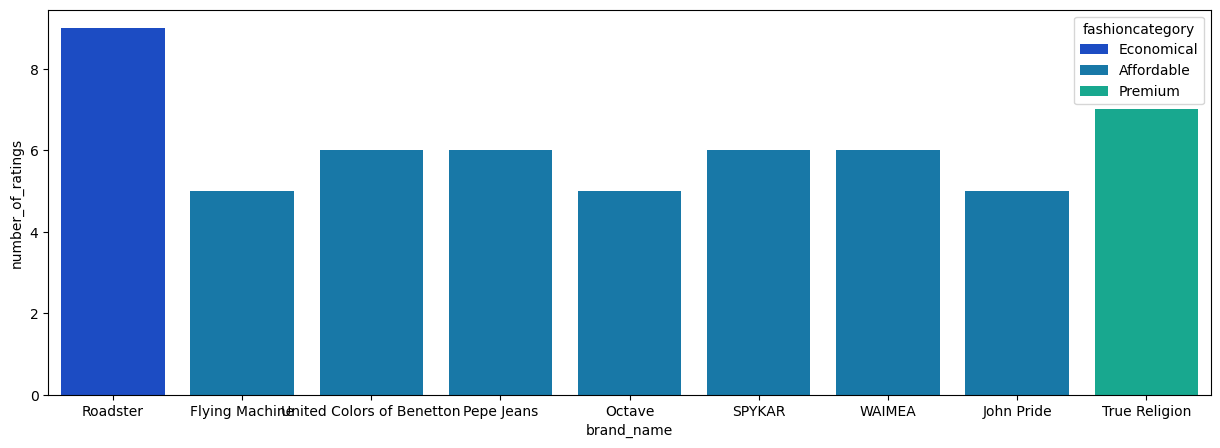

In [35]:
plt.figure(figsize=(15,5))
sns.barplot(x=Toprated['brand_name'],y=Toprated['number_of_ratings'],hue=Toprated['fashioncategory'],palette='winter')
plt.show()

In [36]:
df['high_rating']=(df['ratings']>=4).astype(int)
df.high_rating.value_counts(normalize=True)

high_rating
1    0.610975
0    0.389025
Name: proportion, dtype: float64

In [37]:
import plotly.express as px
fig=px.pie(df,names='high_rating',color='high_rating',
           color_discrete_map={1:'Green',
                              0:'Red'})
fig.show()

In [38]:
Highend=df.loc[df['high_rating']==1]
Highend=Highend.head(100)

In [ ]:
fig=px.sunburst(Highend,path=['brand_name','price','MRP','discount_percent','ratings','number_of_ratings','sales'])
fig.show()

In [ ]:
sns.boxplot(df)

In [39]:
for i in df:
    if df[i].dtypes in ['int64','float64']:
        q1=df[i].quantile(0.75)
        q3=df[i].quantile(0.25)
        iqr=q3-q1
        ul=q1+1.5*iqr
        ll=q3-1.5*iqr
        df[i].clip(upper=ul,lower=ll,inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9108\2913403554.py:8: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\Administrator\AppData\Local\Temp\ipykernel_9108\2913403554.py:8: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

<Axes: >

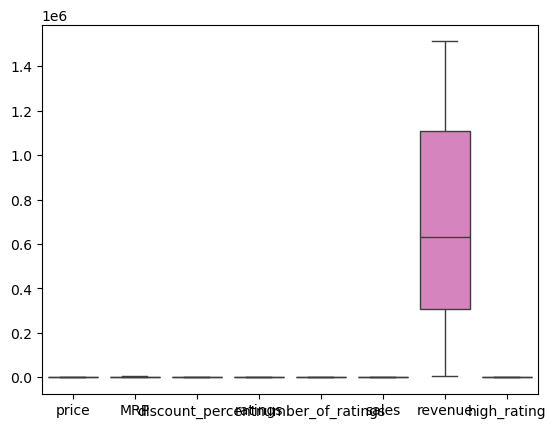

In [40]:
sns.boxplot(df)

## Breaking into two parts

In [41]:
df.head()

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings,sales,revenue,fashioncategory,high_rating
0,WROGN,Men Loose Fit Cotton Jeans,1374,2499.0,0.45,4.2,57,112,153888.0,Affordable,1
1,Flying Machine,Men Slim Fit Jeans,1829,2999.0,0.39,4.4,5,445,813905.0,Affordable,1
2,Roadster,Men Pure Cotton Jeans,974,2499.0,0.61,3.6,103,870,847380.0,Economical,0
3,Bene Kleed,Relaxed Fit Denim Jeans,873,2299.0,0.62,4.0,103,280,244440.0,Economical,1
4,Levis,Men 511 Slim Fit Jeans,1478,2899.0,0.49,4.3,103,116,171448.0,Affordable,1


In [42]:
quantitative=df.select_dtypes(include=[np.number])
quantitative.head()

,price,MRP,discount_percent,ratings,number_of_ratings,sales,revenue,high_rating
0,1374,2499.0,0.45,4.2,57,112,153888.0,1
1,1829,2999.0,0.39,4.4,5,445,813905.0,1
2,974,2499.0,0.61,3.6,103,870,847380.0,0
3,873,2299.0,0.62,4.0,103,280,244440.0,1
4,1478,2899.0,0.49,4.3,103,116,171448.0,1


<Axes: >

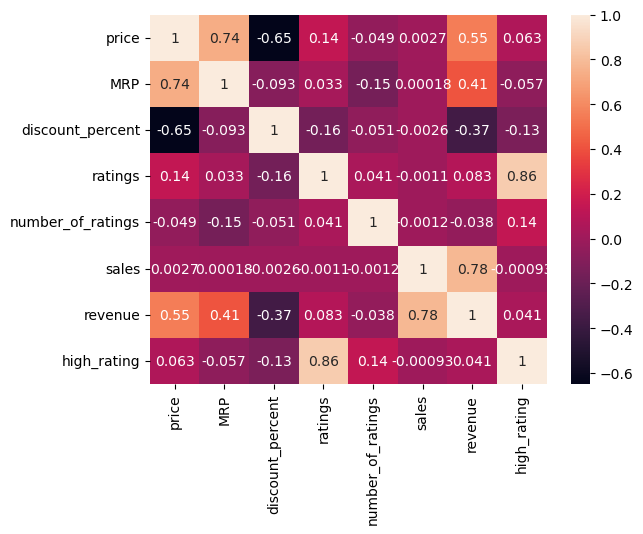

In [43]:
correlation=quantitative.corr()
sns.heatmap(correlation,annot=True)

In [44]:
qualitative=df.select_dtypes(include=['object'])
qualitative.head()

,brand_name,pants_description,fashioncategory
0,WROGN,Men Loose Fit Cotton Jeans,Affordable
1,Flying Machine,Men Slim Fit Jeans,Affordable
2,Roadster,Men Pure Cotton Jeans,Economical
3,Bene Kleed,Relaxed Fit Denim Jeans,Economical
4,Levis,Men 511 Slim Fit Jeans,Affordable


#### Converting qualitative into number

In [45]:
from sklearn.preprocessing import LabelEncoder
qualitative=qualitative.apply(LabelEncoder().fit_transform)
qualitative.head()

,brand_name,pants_description,fashioncategory
0,391,1168,0
1,130,1802,0
2,300,1520,1
3,49,2426,1
4,210,392,0


In [46]:
Finaldf=pd.concat([qualitative,quantitative],axis=1)
Finaldf.head()

,brand_name,pants_description,fashioncategory,price,MRP,discount_percent,ratings,number_of_ratings,sales,revenue,high_rating
0,391,1168,0,1374,2499.0,0.45,4.2,57,112,153888.0,1
1,130,1802,0,1829,2999.0,0.39,4.4,5,445,813905.0,1
2,300,1520,1,974,2499.0,0.61,3.6,103,870,847380.0,0
3,49,2426,1,873,2299.0,0.62,4.0,103,280,244440.0,1
4,210,392,0,1478,2899.0,0.49,4.3,103,116,171448.0,1


In [47]:
Finaldf.columns.to_list()


['brand_name',
 'pants_description',
 'fashioncategory',
 'price',
 'MRP',
 'discount_percent',
 'ratings',
 'number_of_ratings',
 'sales',
 'revenue',
 'high_rating']

## Data Partition

In [48]:
from sklearn.model_selection import train_test_split
x=Finaldf.drop(['ratings','high_rating','sales','revenue'],axis=1)
y=Finaldf['high_rating']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

## StandardScaler

In [49]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
new_xtrain=sc.fit_transform(x_train)
new_xtest=sc.transform(x_test)

In [50]:
new_xtrain

array([[ 1.39932457,  0.18330949,  1.58386269, ..., -1.42266461,
         0.65103107, -0.12150264],
       [-1.50332148, -0.81058944, -0.58559392, ..., -0.26681385,
         0.87040347, -0.51258602],
       [-1.04731666,  0.5072876 , -0.58559392, ...,  0.02214884,
        -0.95769987, -1.15508016],
       ...,
       [ 0.97839705, -0.30174247, -0.58559392, ...,  1.03351826,
         0.066038  , -1.07127657],
       [-1.04731666,  1.80869117, -0.58559392, ...,  0.02214884,
        -0.95769987, -1.0992111 ],
       [ 0.03131012,  0.08263833, -0.58559392, ...,  1.4669623 ,
        -0.1533344 ,  0.15784264]], shape=(36484, 7))

In [51]:
new_xtest

array([[ 1.24147675, -1.99850915, -0.58559392, ..., -0.26681385,
        -0.1533344 , -0.59638961],
       [ 0.57500817,  0.52559144, -0.58559392, ...,  0.88903692,
        -0.1533344 ,  1.58250354],
       [ 1.24147675, -0.65317635, -0.58559392, ..., -0.70025789,
        -0.51895506,  0.29751528],
       ...,
       [ 1.03978231,  0.53474337, -0.58559392, ...,  1.4669623 ,
         1.52852067, -0.12150264],
       [ 0.86439584,  0.76903262,  1.58386269, ..., -0.62801721,
         1.45539654,  1.58250354],
       [ 1.24147675, -0.65317635, -0.58559392, ..., -0.70025789,
        -0.51895506,  0.29751528]], shape=(15636, 7))

## Model Building

In [52]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression()
classifier.fit(new_xtrain,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [53]:
from sklearn .metrics import confusion_matrix
y_trainpred=classifier.predict(new_xtrain)
confusion_matrix(y_train,y_trainpred)

array([[ 3231, 10919],
       [ 2866, 19468]])

In [54]:
from sklearn.metrics import accuracy_score
print('Accuracy =' ,accuracy_score(y_train,y_trainpred))

Accuracy = 0.6221631400065782


In [55]:
y_testpred=classifier.predict(new_xtest)

In [56]:
from sklearn.metrics import confusion_matrix
confusionmatrix=confusion_matrix(y_test,y_testpred)

In [57]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_testpred))
print(confusionmatrix)

              precision    recall  f1-score   support

           0       0.53      0.23      0.32      6126
           1       0.64      0.87      0.74      9510

    accuracy                           0.62     15636
   macro avg       0.59      0.55      0.53     15636
weighted avg       0.60      0.62      0.57     15636

[[1384 4742]
 [1208 8302]]


### Decision Tree

In [58]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [59]:
high_rating=['0','1']

In [60]:
from sklearn import tree

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

independentvariables=list(x.columns)
high_rating=['1','0']

fig,axes=plt.subplots(nrows=1,ncols=1,dpi=300,figsize=(4,5))
plot_tree(dt,
         feature_names=list(x.columns),
         class_names=high_rating,
         filled=True,
         fontsize=2)

In [61]:
DTtrain=pd.concat([x_train,y_train],axis=1)
DTtrain.head()

,brand_name,pants_description,fashioncategory,price,MRP,discount_percent,number_of_ratings,high_rating
21812,409,1625,1,623,1999.0,0.61,42,1
4514,78,1082,0,1007,2799.0,0.64,28,0
36151,130,1802,0,1829,2999.0,0.39,5,1
31096,126,1620,0,2099,3499.0,0.40,103,0
47199,269,1056,0,2249,3999.0,0.40,22,0


In [62]:
DTtrain['preds']=dt.predict(x_train)
DTtrain.head()

,brand_name,pants_description,fashioncategory,price,MRP,discount_percent,number_of_ratings,high_rating,preds
21812,409,1625,1,623,1999.0,0.61,42,1,1
4514,78,1082,0,1007,2799.0,0.64,28,0,0
36151,130,1802,0,1829,2999.0,0.39,5,1,1
31096,126,1620,0,2099,3499.0,0.40,103,0,0
47199,269,1056,0,2249,3999.0,0.40,22,0,0


In [63]:
from sklearn.metrics import classification_report
report=classification_report(DTtrain['high_rating'],DTtrain['preds'])
print(report)

              precision    recall  f1-score   support

           0       0.97      0.98      0.97     14150
           1       0.99      0.98      0.98     22334

    accuracy                           0.98     36484
   macro avg       0.98      0.98      0.98     36484
weighted avg       0.98      0.98      0.98     36484



In [64]:
params={'min_samples_split':[250,200,150],
       'min_samples_leaf':[100,50,40],
       'max_depth':[3,4,5]}

In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

grid=GridSearchCV(DecisionTreeClassifier(random_state=99),
                params,
                verbose=1,
                cv=3)
grid.fit(x_train,y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


,estimator,DecisionTreeC...ndom_state=99)
,param_grid,"{'max_depth': [3, 4, ...], 'min_samples_leaf': [100, 50, ...], 'min_samples_split': [250, 200, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [66]:
DT=DecisionTreeClassifier(max_depth=5, min_samples_leaf=100, min_samples_split=250,
                       random_state=99)
DT.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,250
,min_samples_leaf,100
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,99
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [68]:
high_rating=['0','1']

In [ ]:
from sklearn import tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

fig,axes=plt.subplots(nrows=1,ncols=1,dpi=300,figsize=(4,5))

plot_tree(DT,
         feature_names=list(x.columns),
         class_names=high_rating,
         filled=True,
         node_ids=True,
         fontsize=2)

In [69]:
DTtrain['predicted']=DT.predict(x_train)
DTtrain.head()


,brand_name,pants_description,fashioncategory,price,MRP,discount_percent,number_of_ratings,high_rating,preds,predicted
21812,409,1625,1,623,1999.0,0.61,42,1,1,1
4514,78,1082,0,1007,2799.0,0.64,28,0,0,1
36151,130,1802,0,1829,2999.0,0.39,5,1,1,1
31096,126,1620,0,2099,3499.0,0.40,103,0,0,0
47199,269,1056,0,2249,3999.0,0.40,22,0,0,1


In [70]:
report=classification_report(DTtrain['high_rating'],DTtrain['predicted'])
print(report)

              precision    recall  f1-score   support

           0       0.75      0.59      0.66     14150
           1       0.77      0.87      0.82     22334

    accuracy                           0.76     36484
   macro avg       0.76      0.73      0.74     36484
weighted avg       0.76      0.76      0.76     36484



In [71]:
matrix=confusion_matrix(DTtrain['high_rating'],DTtrain['predicted'])
print(matrix)

[[ 8377  5773]
 [ 2822 19512]]


In [79]:
DTtest=pd.concat([x_test,y_test],axis=1)
DTtest.head()

,brand_name,pants_description,fashioncategory,price,MRP,discount_percent,number_of_ratings,high_rating
8481,391,433,0,1399,2799.0,0.50,25,1
26182,315,1812,0,1799,3599.0,0.50,103,1
27700,391,1168,0,1374,2499.0,0.45,57,1
8952,372,1082,0,1829,2999.0,0.39,5,1
23094,315,1570,0,1899,3799.0,0.50,31,0


In [73]:
DTtest['predicted']=DT.predict(x_test)
DTtest.head()

,brand_name,pants_description,fashioncategory,price,MRP,discount_percent,number_of_ratings,high_rating,predicted
8481,391,433,0,1399,2799.0,0.50,25,1,1
26182,315,1812,0,1799,3599.0,0.50,103,1,1
27700,391,1168,0,1374,2499.0,0.45,57,1,1
8952,372,1082,0,1829,2999.0,0.39,5,1,1
23094,315,1570,0,1899,3799.0,0.50,31,0,0


In [81]:
x_test.columns

Index(['brand_name', 'pants_description', 'fashioncategory', 'price', 'MRP',
       'discount_percent', 'number_of_ratings'],
      dtype='object')

In [74]:
report=classification_report(DTtest['high_rating'],DTtest['predicted'])
print(report)

matrix=confusion_matrix(DTtest['high_rating'],DTtest['predicted'])
print(matrix)

              precision    recall  f1-score   support

           0       0.75      0.59      0.66      6126
           1       0.77      0.87      0.81      9510

    accuracy                           0.76     15636
   macro avg       0.76      0.73      0.74     15636
weighted avg       0.76      0.76      0.75     15636

[[3591 2535]
 [1228 8282]]


In [75]:
matrix=confusion_matrix(DTtest['high_rating'],DTtest['predicted'])
print(matrix)

[[3591 2535]
 [1228 8282]]


In [ ]:
##deployment

In [76]:
import pickle
pickle.dump(DT,open("model.pkl","wb"))